In [54]:
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn.functional as F

In [55]:
torch.cuda.is_available()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
torch.cuda.device_count() # returns 1 in my case


if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

cuda:0
GPU: NVIDIA RTX A6000 is available.


In [56]:
import os
import random
from pathlib import Path
from shutil import copy2

# === Setup ===
INPUT_DIR = "/home/HardDisk/Satang/thesis_proj/New_60/15/raw_data_normalized_5"
OUTPUT_BASE = "/home/HardDisk/Satang/thesis_proj/New_60/15/split_tws_5"  # You can change this if needed
SPLIT_RATIOS = (0.7, 0.15, 0.15)  # Train, Val, Test
SEED = 42

# === Prepare output folders ===
splits = ['train', 'val', 'test']
for split in splits:
    for cls in os.listdir(INPUT_DIR):
        os.makedirs(os.path.join(OUTPUT_BASE, split, cls), exist_ok=True)

# === Perform the split ===
random.seed(SEED)

for cls in sorted(os.listdir(INPUT_DIR)):
    class_path = os.path.join(INPUT_DIR, cls)
    if not os.path.isdir(class_path):
        continue

    files = sorted([f for f in os.listdir(class_path) if f.endswith(".csv")])
    random.shuffle(files)

    n_total = len(files)
    n_train = int(n_total * SPLIT_RATIOS[0])
    n_val = int(n_total * SPLIT_RATIOS[1])
    n_test = n_total - n_train - n_val

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    for f in train_files:
        src = os.path.join(class_path, f)
        dst = os.path.join(OUTPUT_BASE, "train", cls, f)
        copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_path, f)
        dst = os.path.join(OUTPUT_BASE, "val", cls, f)
        copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_path, f)
        dst = os.path.join(OUTPUT_BASE, "test", cls, f)
        copy2(src, dst)

print("✅ Done! Files have been split and copied to:", OUTPUT_BASE)


✅ Done! Files have been split and copied to: /home/HardDisk/Satang/thesis_proj/New_60/15/split_tws_5


In [57]:
from pathlib import Path
import numpy as np
import pandas as pd

# Config
DATA_ROOT = Path("/home/HardDisk/Satang/thesis_proj/New_60/15/split_tws_5")  # Folder structure: split/train/class/*.csv

INNER_STRIDE = 1
NUM_FEATURES = 5

def extract_x_vectors(csv_path, t_window, inner_stride):
    df = pd.read_csv(csv_path, header=None).values  # shape: (time, 8)
    x_vectors = []

    for i in range(0, len(df) - t_window + 1, inner_stride):
        window = df[i:i + t_window, :]  # shape: (t_window, 8)
        vector = np.mean(window, axis=0)
        x_vectors.append(vector)

    return np.array(x_vectors)  # shape: (N_x, 8)

def extract_time_aware_samples(x_vectors, t_d, t_window):
    sample_len = t_d - t_window + 1
    outer_stride = max(1, int(0.25 * sample_len))  # 75% overlap → 25% stride

    samples = []
    for i in range(0, len(x_vectors) - sample_len + 1, outer_stride):
        chunk = x_vectors[i:i + sample_len]
        samples.append(chunk)

    return np.stack(samples) if samples else np.empty((0, sample_len, NUM_FEATURES))

def load_dataset_by_split(split, t_window, t_d):
    data = []
    labels = []
    split_path = DATA_ROOT / split

    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue

        for file in sorted(class_dir.glob("*.csv")):
            x_vecs = extract_x_vectors(file, t_window, INNER_STRIDE)
            samples = extract_time_aware_samples(x_vecs, t_d, t_window)

            data.extend(samples)
            labels.extend([class_dir.name] * len(samples))

    return np.array(data), np.array(labels)

# Test configuration (adjust as needed)
T_WINDOW = 15
T_D = 60
sample_len = T_D - T_WINDOW + 1

X_train, y_train = load_dataset_by_split("train", T_WINDOW, T_D)
X_train.shape, y_train.shape, sample_len
# Example call: load training data
X_train, y_train =load_dataset_by_split("train", T_WINDOW, T_D)
X_val, y_val = load_dataset_by_split("val", T_WINDOW,T_D)
X_test, y_test = load_dataset_by_split("test", T_WINDOW,T_D)


X_train.shape, y_train.shape



((3315, 46, 5), (3315,))

In [58]:
def split_csv_into_chunks(input_root, output_root, t_window, t_d, num_features=5):
    input_root = Path(input_root)
    output_root = Path(output_root)
    sample_counter = {}

    chunk_len = t_d - t_window + 1
    stride = max(1, int(0.25 * chunk_len))  # 75% overlap

    for split in ['train', 'val', 'test']:
        for class_dir in (input_root / split).iterdir():
            if not class_dir.is_dir():
                continue

            class_name = class_dir.name
            out_class_dir = output_root / split / class_name
            out_class_dir.mkdir(parents=True, exist_ok=True)

            for file in sorted(class_dir.glob("*.csv")):
                df = pd.read_csv(file, header=None).values
                if df.shape[1] != num_features:
                    continue

                sample_counter.setdefault(class_name, 0)
                for i in range(0, len(df) - chunk_len + 1, stride):
                    chunk = df[i:i + chunk_len]
                    sample_counter[class_name] += 1

                    out_path = out_class_dir / f"{class_name}_sample_{sample_counter[class_name]:04d}.csv"
                    pd.DataFrame(chunk).to_csv(out_path, index=False, header=False)

    print(f"✅ Done: All files split into ({chunk_len}, {num_features}) samples with stride={stride}.")

split_csv_into_chunks(
    input_root="/home/HardDisk/Satang/thesis_proj/New_60/15/split_tws_5",
    output_root="/home/HardDisk/Satang/thesis_proj/New_60/15/split_tws_5/X_csv_split_46",
    t_window=15,
    t_d=60,
    num_features=5
)



✅ Done: All files split into (46, 5) samples with stride=11.


In [59]:
# === CONFIG ===
INPUT_DIR = "/home/HardDisk/Satang/thesis_proj/New_60/15/split_tws_5/X_csv_split_46"
CHUNK_SIZE = 46
NUM_FEATURES = 5
NUM_EPOCHS = 50
BATCH_SIZE = 32
K_FOLDS = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [60]:
# === HELPERS ===
def collate_fn(batch):
    streams, labels = zip(*batch)
    streams = list(zip(*streams))
    streams = [torch.stack(s) for s in streams]
    labels = torch.tensor(labels)
    return streams, labels

def compute_class_weights(labels, device):
    counter = Counter(labels)
    total = sum(counter.values())
    weights = [np.log(total / (counter[i] + 1)) for i in range(len(counter))]
    return torch.tensor(weights, dtype=torch.float).to(device)

def print_model_info(model):
    print("Model Architecture:")
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

def plot_loss_curve(train_losses, val_losses):
    epochs = range(len(train_losses))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs, val_losses, label='Val Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_accuracy_curve(train_acc, val_acc):
    epochs = range(len(train_acc))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_acc, label='Train Accuracy', color='green')
    plt.plot(epochs, val_acc, label='Val Accuracy', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [61]:
# === DATASET CLASS ===
class MultiStreamDataset(Dataset):
    def __init__(self, data, labels, label_encoder, augment=False):
        self.data = data
        self.labels = label_encoder.transform(labels)
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def augment_stream(self, stream):
        jitter = np.random.normal(0, 0.01, stream.shape)
        scale = np.random.normal(1.0, 0.05, stream.shape)
        return stream * scale + jitter

    def __getitem__(self, idx):
        sample = self.data[idx]
        # if idx == 0:
        #     print("🔍 Raw feature sample:")
        #     print(sample)
        #     print("Min:", sample.min(), "Max:", sample.max())
        streams = [sample[:, i].reshape(1, -1).astype(np.float32) for i in range(sample.shape[1])]
        if self.augment:
            streams = [self.augment_stream(s.copy()) for s in streams]
        streams = [torch.tensor(s).float() for s in streams]
        label = torch.tensor(self.labels[idx])
        return streams, label


In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.downsample(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(self.bn2(self.conv2(out)))
        return F.relu(out + identity)

class MultiStreamCNN(nn.Module):
    def __init__(self, input_length=32, num_classes=12):
        super().__init__()
        self.streams = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(1, 32),
                ResidualBlock(32, 64),
                ResidualBlock(64, 128),
                nn.MaxPool1d(2),
                ResidualBlock(128, 256, dilation=2),
                ResidualBlock(256, 256, dilation=2),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten()
            ) for _ in range(5)
        ])
        self.fc = nn.Sequential(
            nn.LayerNorm(256 * 5),
            nn.Linear(256 * 5, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),   # ✅ extra
            nn.GELU(),             # ✅ extra
            nn.Linear(128, num_classes)
        )
        self.proj = nn.Linear(256 * 5, 128)  # ✅ New: for feature projection

    def forward(self, streams, return_features=False):
        features = [self.streams[i](streams[i]) for i in range(5)]
        x = torch.cat(features, dim=1)
        logits = self.fc(x)
        if return_features:
            feat_proj = self.proj(x)         # ✅ Project [B, 2048] → [B, 128]
            return logits, feat_proj
        return logits  # ✅ Fix: add this

In [63]:

# === COLLATE FUNCTION ===
def collate_fn(batch):
    streams, labels = zip(*batch)
    streams = list(zip(*streams))
    streams = [torch.stack(s) for s in streams]
    labels = torch.tensor(labels)
    return streams, labels

# === LOAD SPLIT FUNCTION ===
def load_split_from_folder(split_dir, expected_shape):
    X, y = [], []
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        for fname in sorted(os.listdir(class_path)):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                chunk = pd.read_csv(fpath, header=None).values
                if chunk.shape == expected_shape:
                    X.append(chunk)
                    y.append(class_name)
    return np.array(X), np.array(y)

In [64]:
# === APPLY SMOTE ===
def apply_smote_on_training(X_chunks, y_labels, chunk_size, num_features):
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_labels)

    smote_encoder = LabelEncoder()
    y_encoded_for_smote = smote_encoder.fit_transform(y_labels)

    X_flat = X_chunks.reshape(X_chunks.shape[0], -1)
    X_resampled, y_resampled = SMOTE().fit_resample(X_flat, y_encoded_for_smote)

    X_res = X_resampled.reshape(-1, chunk_size, num_features)
    y_res_str = smote_encoder.inverse_transform(y_resampled)

    return X_res, y_res_str, label_encoder

# === LOAD DATASETS ===
expected_shape = (CHUNK_SIZE, NUM_FEATURES)

X_train_raw, y_train_raw = load_split_from_folder(os.path.join(INPUT_DIR, "train"), expected_shape)
X_val_raw,   y_val_raw   = load_split_from_folder(os.path.join(INPUT_DIR, "val"), expected_shape)

# === SMOTE ONLY ON TRAIN ===
X_train_balanced, y_train_str, label_encoder = apply_smote_on_training(
    X_train_raw, y_train_raw, CHUNK_SIZE, NUM_FEATURES
)

# === CREATE DATASETS ===
train_dataset = MultiStreamDataset(X_train_balanced, y_train_str, label_encoder, augment=True)
val_dataset   = MultiStreamDataset(X_val_raw, y_val_raw, label_encoder, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [65]:

# === CLASS WEIGHTING ===
def compute_class_weights(labels, device):
    from collections import Counter
    total = len(labels)
    counts = Counter(labels)
    weights = [np.log(total / (counts[i] + 1)) for i in range(len(counts))]
    return torch.tensor(weights, dtype=torch.float).to(device)

class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device="cpu")

In [66]:
# # === LOAD ORIGINAL DATA ===
# X_chunks, y_labels = [], []
# for class_name in sorted(os.listdir(INPUT_DIR)):
#     class_path = os.path.join(INPUT_DIR, class_name)
#     if not os.path.isdir(class_path):
#         continue
#     for fname in sorted(os.listdir(class_path)):
#         if fname.endswith(".csv"):
#             fpath = os.path.join(class_path, fname)
#             chunk = pd.read_csv(fpath, header=None).values
#             if chunk.shape == (CHUNK_SIZE, NUM_FEATURES):
#                 X_chunks.append(chunk)
#                 y_labels.append(class_name)

# X_chunks = np.array(X_chunks)
# y_labels = np.array(y_labels)
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y_labels)
# X_flat = X_chunks.reshape(X_chunks.shape[0], -1)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_flat)


In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def train_model(model, train_loader, val_loader, device, epochs=50, lr=0.001, class_weights=None):
    
    print("🔍 Class Weights Tensor:")
    print(class_weights)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0
    best_model_path = "teacher_full.pth"
    printed_shape = False

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            if not printed_shape:
                print("🔍 Shape of one stream sample:", streams[0].shape)
                printed_shape = True

            outputs = model(streams)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)

                outputs = model(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {total_loss:.4f} - Val Loss: {val_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        # Save best model so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

    # Load the best model before returning
    model.load_state_dict(torch.load(best_model_path))

    return train_accuracies, val_accuracies, train_losses, val_losses


In [68]:
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import confusion_matrix, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns

# # === CONFIG (shared from earlier) ===
# K_FOLDS = 5
# NUM_EPOCHS = 50
# device = "cpu"  # or "cuda" if GPU is available

# # === PREPROCESS DATA ===
# # Load once and scale
# X_all, y_all = load_split_from_folder(os.path.join(INPUT_DIR, "train"), (CHUNK_SIZE, NUM_FEATURES))
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y_all)
# X_flat = X_all.reshape(X_all.shape[0], -1)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_flat)

# # === K-FOLD TRAINING LOOP ===
# skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
# all_preds_global, all_labels_global = [], []
# all_train_acc, all_val_acc = [], []

# for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_encoded)):
#     print(f"\n--- Fold {fold + 1} / {K_FOLDS} ---")
#     X_train, y_train = X_scaled[train_idx], y_encoded[train_idx]
#     X_val, y_val     = X_scaled[val_idx],   y_encoded[val_idx]

#     # Apply SMOTE
#     X_train_res, y_train_res = SMOTE().fit_resample(X_train, y_train)

#     # Reshape for CNN
#     X_train_final = X_train_res.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
#     y_train_final = label_encoder.inverse_transform(y_train_res)
#     X_val_final = X_val.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
#     y_val_final = label_encoder.inverse_transform(y_val)

#     # Create datasets and loaders
#     train_dataset = MultiStreamDataset(X_train_final, y_train_final, label_encoder, augment=True)
#     val_dataset   = MultiStreamDataset(X_val_final,   y_val_final,   label_encoder, augment=False)

#     train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
#     val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=collate_fn)

#     model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
#     print_model_info(model)

#     class_weights_tensor = compute_class_weights(train_dataset.labels, device)
#     train_accs, val_accs, train_losses, val_losses = train_model(
#         model, train_loader, val_loader, device, epochs=NUM_EPOCHS, class_weights=class_weights_tensor
#     )

#     all_train_acc.append(train_accs[-1])
#     all_val_acc.append(val_accs[-1])
#     plot_loss_curve(train_losses, val_losses)
#     plot_accuracy_curve(train_accs, val_accs)

#     # Validation prediction for confusion matrix
#     model.eval()
#     with torch.no_grad():
#         for streams, labels in val_loader:
#             streams = [s.to(device) for s in streams]
#             labels = labels.to(device)
#             outputs = model(streams)
#             preds = torch.argmax(outputs, dim=1)
#             all_preds_global.extend(preds.cpu().numpy())
#             all_labels_global.extend(labels.cpu().numpy())

# # === FINAL REPORT ===
# cm = confusion_matrix(all_labels_global, all_preds_global)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
# plt.title('Combined Confusion Matrix (All Folds)')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.tight_layout()
# plt.show()

# print("\nFinal Combined Classification Report (All Folds):\n")
# print(classification_report(all_labels_global, all_preds_global, target_names=label_encoder.classes_))
# print(f"\nAverage Final Training Accuracy: {np.mean(all_train_acc):.4f}")
# print(f"Average Final Validation Accuracy: {np.mean(all_val_acc):.4f}")


In [69]:

# === UTILS ===
def load_split_from_folder(split_dir, expected_shape):
    X, y = [], []
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        for fname in sorted(os.listdir(class_path)):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                chunk = pd.read_csv(fpath, header=None).values
                if chunk.shape == expected_shape:
                    X.append(chunk)
                    y.append(class_name)
    return np.array(X), np.array(y)

# === LOAD DATA FROM FOLDER STRUCTURE ===
expected_shape = (CHUNK_SIZE, NUM_FEATURES)
X_train_raw, y_train_raw = load_split_from_folder(os.path.join(INPUT_DIR, "train"), expected_shape)
X_val_raw, y_val_raw     = load_split_from_folder(os.path.join(INPUT_DIR, "val"), expected_shape)

# === ENCODE LABELS & APPLY SMOTE ===
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)

X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_resampled, y_resampled = SMOTE().fit_resample(X_train_flat, y_train_encoded)
X_train_bal = X_resampled.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
y_train_str = label_encoder.inverse_transform(y_resampled)

# === BUILD DATASETS AND LOADERS ===
train_dataset = MultiStreamDataset(X_train_bal, y_train_str, label_encoder, augment=True)
val_dataset   = MultiStreamDataset(X_val_raw, y_val_raw, label_encoder, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# === CLASS WEIGHTS ===
class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device)


=== 🧠 Retraining Teacher Model ===
🔍 Finding optimal learning rate...


 90%|█████████ | 180/200 [00:09<00:01, 18.47it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 4.94E-04


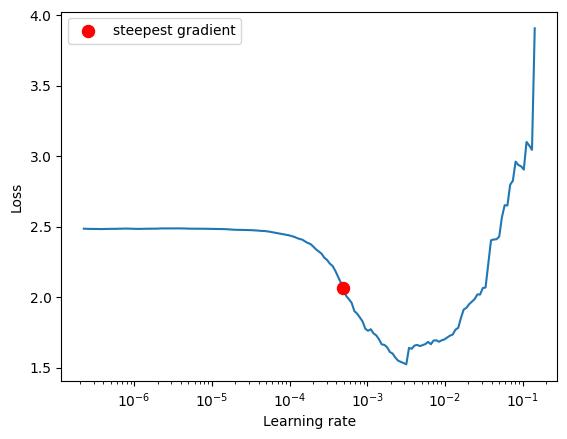

🔍 Class Weights Tensor:
tensor([2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834, 2.4834,
        2.4834, 2.4834, 2.4834], device='cuda:0')
🔍 Shape of one stream sample: torch.Size([32, 1, 46])
Epoch 1/50 - Train Loss: 265.6941 - Val Loss: 19.9942 - Train Acc: 0.6729 - Val Acc: 0.7063
Epoch 2/50 - Train Loss: 107.4373 - Val Loss: 13.3530 - Train Acc: 0.8516 - Val Acc: 0.7899
Epoch 3/50 - Train Loss: 75.6158 - Val Loss: 12.2478 - Train Acc: 0.8964 - Val Acc: 0.8139
Epoch 4/50 - Train Loss: 61.0928 - Val Loss: 11.1985 - Train Acc: 0.9154 - Val Acc: 0.8253
Epoch 5/50 - Train Loss: 48.6769 - Val Loss: 7.5611 - Train Acc: 0.9312 - Val Acc: 0.8937
Epoch 6/50 - Train Loss: 38.5891 - Val Loss: 6.8088 - Train Acc: 0.9482 - Val Acc: 0.9127
Epoch 7/50 - Train Loss: 36.5639 - Val Loss: 6.1910 - Train Acc: 0.9508 - Val Acc: 0.9228
Epoch 8/50 - Train Loss: 30.5884 - Val Loss: 9.3126 - Train Acc: 0.9600 - Val Acc: 0.8684
Epoch 9/50 - Train Loss: 29.5719 - Val Loss: 8.1627 - Train Acc: 0

/tmp/ipykernel_696185/2186331669.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


In [70]:
from torch_lr_finder import LRFinder

# === 🔁 LEARNING RATE FINDER ===
print("\n=== 🧠 Retraining Teacher Model ===")
model_for_lr = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model_for_lr.parameters(), lr=1e-7)  # Fresh model + optimizer

print("🔍 Finding optimal learning rate...")
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
lr_finder = LRFinder(model_for_lr, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=1, num_iter=200)
lr_finder.plot()
lr_finder.reset()

# === Use best LR after checking the LR plot
BEST_LR = 0.0001  # Replace this based on your LR curve

# === Train Teacher
final_teacher = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_)).to(device)
train_accs, val_accs, train_losses, val_losses = train_model(
    final_teacher,
    train_loader,
    val_loader=val_loader,
    device=device,
    epochs=NUM_EPOCHS,
    class_weights=class_weights_tensor,
    lr=BEST_LR
)

# === Save model

print("✅ Final teacher model saved as 'teacher_smote_train_only.pth'")

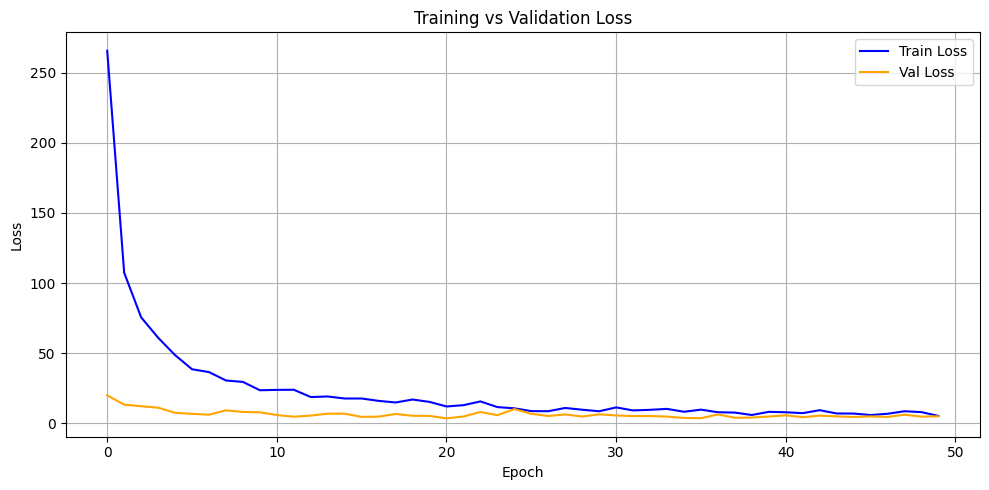

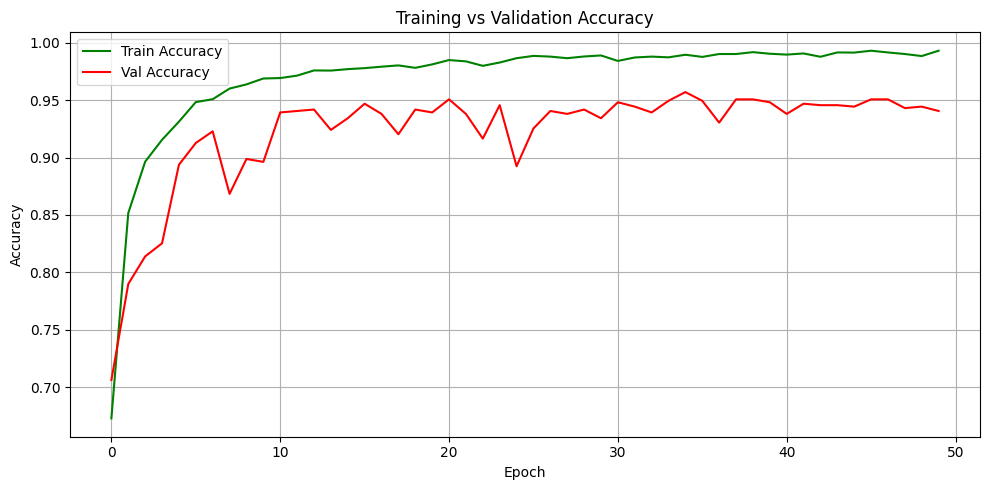

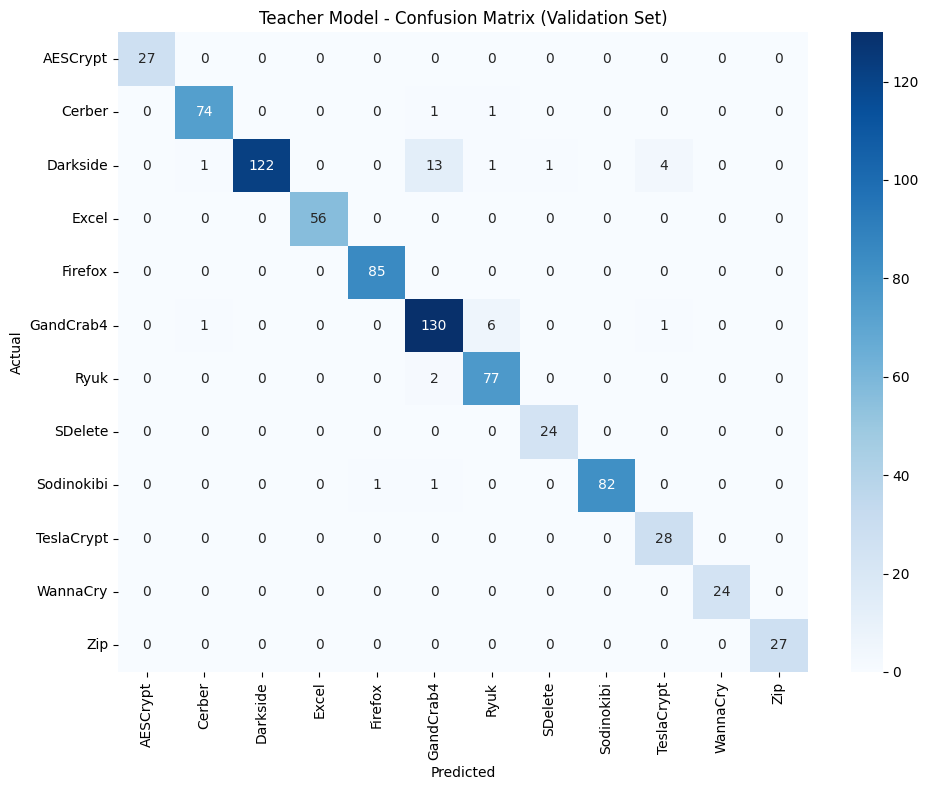


Final Classification Report (Teacher):

              precision    recall  f1-score   support

    AESCrypt       1.00      1.00      1.00        27
      Cerber       0.97      0.97      0.97        76
    Darkside       1.00      0.86      0.92       142
       Excel       1.00      1.00      1.00        56
     Firefox       0.99      1.00      0.99        85
   GandCrab4       0.88      0.94      0.91       138
        Ryuk       0.91      0.97      0.94        79
     SDelete       0.96      1.00      0.98        24
  Sodinokibi       1.00      0.98      0.99        84
  TeslaCrypt       0.85      1.00      0.92        28
    WannaCry       1.00      1.00      1.00        24
         Zip       1.00      1.00      1.00        27

    accuracy                           0.96       790
   macro avg       0.96      0.98      0.97       790
weighted avg       0.96      0.96      0.96       790


Final Training Accuracy: 0.9930
Final Validation Accuracy: 0.9405


In [71]:
# === 🔍 Plot training curves
plot_loss_curve(train_losses, val_losses)
plot_accuracy_curve(train_accs, val_accs)

# === 📊 Evaluate on validation set (same used during training)
final_teacher.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = final_teacher(streams)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Confusion Matrix & Report
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Teacher Model - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Classification Report (Teacher):\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

print(f"\nFinal Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")

🧠 Multi-class AUC (macro): 0.9993


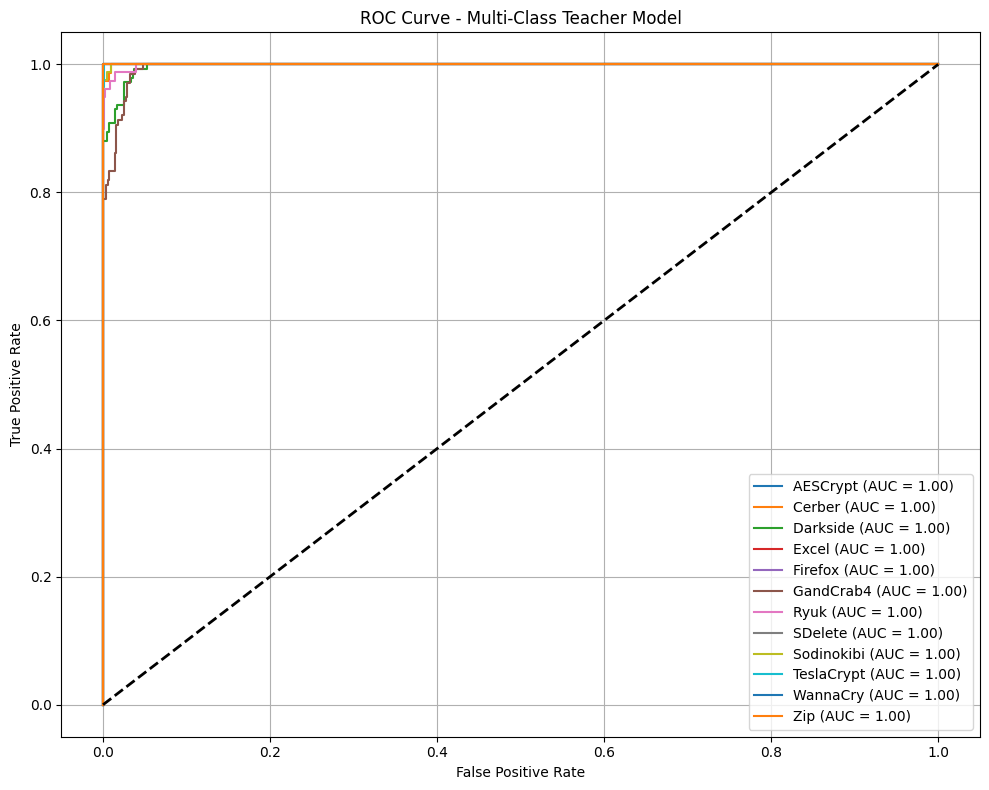

In [72]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# === 1. Get predictions on validation set ===
final_teacher.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.cpu().numpy()
        outputs = final_teacher(streams)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        
        y_probs.extend(probs)
        y_true.extend(labels)

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# === 2. Binarize labels for ROC AUC ===
y_true_bin = label_binarize(y_true, classes=range(len(label_encoder.classes_)))

# === 3. Compute AUC score (macro-average) ===
auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
print(f"🧠 Multi-class AUC (macro): {auc_macro:.4f}")

# === 4. Plot ROC curves per class ===
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class Teacher Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [73]:
import torch
import torch.nn as nn
import time
import os
import psutil
import numpy as np
from thop import profile  
def get_model_size(model):
    temp_path = "temp_model.pth"
    torch.save(model.state_dict(), temp_path)
    size = os.path.getsize(temp_path) / (1024 ** 2)  # in MB
    os.remove(temp_path)
    return size

def measure_latency(model, input_shape=(1, 1, 32), n_runs=100):
    model.eval()
    inputs = [torch.randn(input_shape) for _ in range(n_runs)]
    with torch.no_grad():
        start = time.time()
        for inp in inputs:
            model(inp.unsqueeze(0))
        end = time.time()
    avg_latency = (end - start) / n_runs * 1000  # in ms
    return avg_latency

def measure_cpu_usage(model, input_tensor, duration=2):
    model.eval()
    process = psutil.Process(os.getpid())
    cpu_percent_before = process.cpu_percent(interval=None)
    
    with torch.no_grad():
        start_time = time.time()
        while time.time() - start_time < duration:
            model(input_tensor)
    
    cpu_percent_after = process.cpu_percent(interval=None)
    return (cpu_percent_after - cpu_percent_before) / duration

def evaluate_model_stats(model):
    device = next(model.parameters()).device
    dummy_inputs = [torch.randn(1, 1, 32).to(device) for _ in range(8)]

    # Compute MACs and Params
    macs, params = profile(model, inputs=(dummy_inputs,), verbose=False)
    flops = 2 * macs

    # Model size
    size = get_model_size(model)

    # Latency on CPU
    model_cpu = model.to("cpu")
    dummy_inputs_cpu = [inp.to("cpu") for inp in dummy_inputs]

    def measure_latency(model, inputs, n_runs=100):
        model.eval()
        with torch.no_grad():
            start = time.time()
            for _ in range(n_runs):
                model(inputs)
            end = time.time()
        return (end - start) / n_runs * 1000

    def measure_cpu_usage(model, inputs, duration=2):
        model.eval()
        process = psutil.Process(os.getpid())
        num_cpus = psutil.cpu_count(logical=True)

        _ = process.cpu_percent(interval=None)  # warm-up
        
        with torch.no_grad():
            start_time = time.time()
            while time.time() - start_time < duration:
                model(inputs)

        total_cpu_percent = process.cpu_percent(interval=None)
        return total_cpu_percent / num_cpus

    latency = measure_latency(model_cpu, dummy_inputs_cpu)
    cpu_usage = measure_cpu_usage(model_cpu, dummy_inputs_cpu)

    return {
        "Model Size (MB)": round(size, 4),
        "Latency (ms)": round(latency, 3),
        "MACs": macs,
        "FLOPs": flops,
        "Params": params,
        "CPU Usage (%)": round(cpu_usage, 2)
    }

# === Run
final_teacher.eval()
stats = evaluate_model_stats(final_teacher)
for k, v in stats.items():
    print(f"{k}: {v}")

Model Size (MB): 19.8346
Latency (ms): 34.256
MACs: 76029696.0
FLOPs: 152059392.0
Params: 4981164.0
CPU Usage (%): 49.55


/tmp/ipykernel_696185/3475220102.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("teacher_full.pth"))


=== 🧪 Final Test Set Classification Report ===
              precision    recall  f1-score   support

    AESCrypt     1.0000    1.0000    1.0000        27
      Cerber     1.0000    0.9865    0.9932        74
    Darkside     0.9925    0.9429    0.9670       140
       Excel     1.0000    1.0000    1.0000        74
     Firefox     0.9880    1.0000    0.9939        82
   GandCrab4     0.9178    0.9504    0.9338       141
        Ryuk     0.9294    0.9753    0.9518        81
     SDelete     1.0000    1.0000    1.0000        27
  Sodinokibi     1.0000    0.9277    0.9625        83
  TeslaCrypt     0.8810    0.9737    0.9250        38
    WannaCry     1.0000    1.0000    1.0000        32
         Zip     1.0000    1.0000    1.0000        27

    accuracy                         0.9697       826
   macro avg     0.9757    0.9797    0.9773       826
weighted avg     0.9711    0.9697    0.9700       826



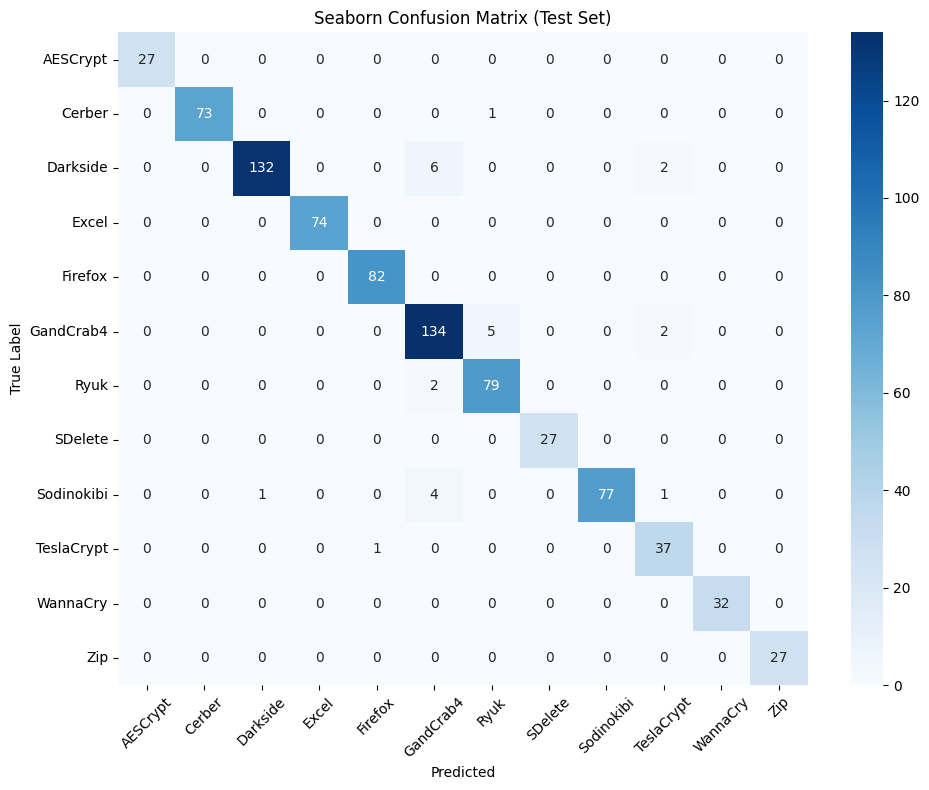

In [74]:
expected_shape = (CHUNK_SIZE, NUM_FEATURES)
X_test, y_test = load_split_from_folder(os.path.join(INPUT_DIR, "test"), expected_shape)
y_test_str = y_test

test_dataset = MultiStreamDataset(X_test, y_test_str, label_encoder, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Rebuild same model architecture
model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("teacher_full.pth"))
model.to(device)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for streams, labels in test_loader:
        # Move to device
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)

        outputs = model(streams)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Inverse-transform for reporting
pred_labels_str = label_encoder.inverse_transform(all_preds)
true_labels_str = label_encoder.inverse_transform(all_labels)

# === 5. Classification Report
print("=== 🧪 Final Test Set Classification Report ===")
print(classification_report(true_labels_str, pred_labels_str, digits=4))

# === 6. Seaborn Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Seaborn Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [75]:
import torch
import torch.nn as nn

class StudentCNN(nn.Module):
    def __init__(self, input_length, num_classes=12):
        super().__init__()
        self.streams = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, 4, kernel_size=3, padding=1),  # reduced filters
                nn.ReLU(),
                nn.Conv1d(4, 8, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten()
            ) for _ in range(5)
        ])

        self.fc = nn.Sequential(
            nn.Linear(8 * 5, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        # 🔄 Smaller projection for lightweight feature distillation
        self.proj = nn.Linear(8 * 5, 128)

    def forward(self, streams, return_features=False):
        features = [self.streams[i](streams[i]) for i in range(5)]
        x = torch.cat(features, dim=1)  # Shape: [B, 64]

        if return_features:
            feat_proj = self.proj(x)  # [B, 128]
            return self.fc(x), feat_proj

        return self.fc(x)


In [ ]:
def distillation_loss(student_logits, teacher_logits, true_labels,
                      student_feats, teacher_feats, 
                      T=3.0, alpha=0.3, beta = 0.3 ,gamma=0.1, criterion=None):
    
    if criterion is None:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Hard loss
    hard_loss = criterion(student_logits, true_labels)

    # Soft distillation loss
    soft_teacher = F.softmax(teacher_logits / T, dim=1).detach()
    soft_student = F.log_softmax(student_logits / T, dim=1)
    soft_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T * T)

    # Feature matching loss
    feat_loss = F.mse_loss(student_feats, teacher_feats.detach())

    return alpha * soft_loss + beta * hard_loss + gamma * feat_loss


In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def train_distilled(student, teacher, train_loader, val_loader, device,
                    epochs=50, lr=0.0005, class_weights=None,
                    T=3.0, alpha=0.3, gamma=0.1,
                    save_path="best_student.pth"):

    teacher.eval()
    student.to(device)
    teacher.to(device)

    optimizer = optim.Adam(student.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_acc = 0
    train_losses, train_accuracies, val_accuracies, val_losses = [], [], [], []

    for epoch in range(epochs):
        student.train()
        total_loss = 0
        correct = 0

        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            # Forward pass with feature distillation
            student_logits, student_feats = student(streams, return_features=True)
            with torch.no_grad():
                teacher_logits, teacher_feats = teacher(streams, return_features=True)

            # Compute distillation loss
            loss = distillation_loss(
                student_logits, teacher_logits, labels,
                student_feats, teacher_feats,
                T=T, alpha=alpha, gamma=gamma,
                criterion=criterion
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (student_logits.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        student.eval()
        val_correct = 0
        val_loss = 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)

                outputs = student(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)

        print(f"[Distill] Epoch {epoch+1:02d}/{epochs} - Loss: {total_loss:.4f} "
              f"- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        # Save best model checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student.state_dict(), save_path)

    # Load the best model after full training
    student.load_state_dict(torch.load(save_path))
    return train_accuracies, val_accuracies, train_losses, val_losses


/tmp/ipykernel_696185/170160237.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher.load_state_dict(torch.load("teacher_full.pth", map_location=device))


🔍 Finding optimal learning rate...


100%|██████████| 200/200 [00:02<00:00, 66.67it/s]


Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.16E-02


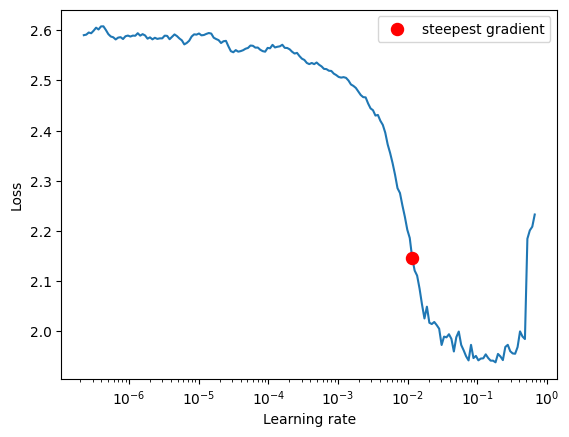

[Distill] Epoch 01/50 - Loss: 1283.2719 - Train Acc: 0.5723 - Val Acc: 0.6481
[Distill] Epoch 02/50 - Loss: 575.4711 - Train Acc: 0.8104 - Val Acc: 0.7532
[Distill] Epoch 03/50 - Loss: 438.6159 - Train Acc: 0.8486 - Val Acc: 0.7608
[Distill] Epoch 04/50 - Loss: 378.4050 - Train Acc: 0.8649 - Val Acc: 0.7823
[Distill] Epoch 05/50 - Loss: 335.0533 - Train Acc: 0.8883 - Val Acc: 0.7810
[Distill] Epoch 06/50 - Loss: 293.0652 - Train Acc: 0.8986 - Val Acc: 0.8177
[Distill] Epoch 07/50 - Loss: 283.4336 - Train Acc: 0.9049 - Val Acc: 0.8544
[Distill] Epoch 08/50 - Loss: 265.4473 - Train Acc: 0.9109 - Val Acc: 0.8620
[Distill] Epoch 09/50 - Loss: 257.3670 - Train Acc: 0.9134 - Val Acc: 0.8684
[Distill] Epoch 10/50 - Loss: 240.6457 - Train Acc: 0.9189 - Val Acc: 0.8861
[Distill] Epoch 11/50 - Loss: 239.7187 - Train Acc: 0.9224 - Val Acc: 0.8443
[Distill] Epoch 12/50 - Loss: 238.0273 - Train Acc: 0.9212 - Val Acc: 0.8861
[Distill] Epoch 13/50 - Loss: 217.5354 - Train Acc: 0.9271 - Val Acc: 0.884

/tmp/ipykernel_696185/215973474.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(save_path))


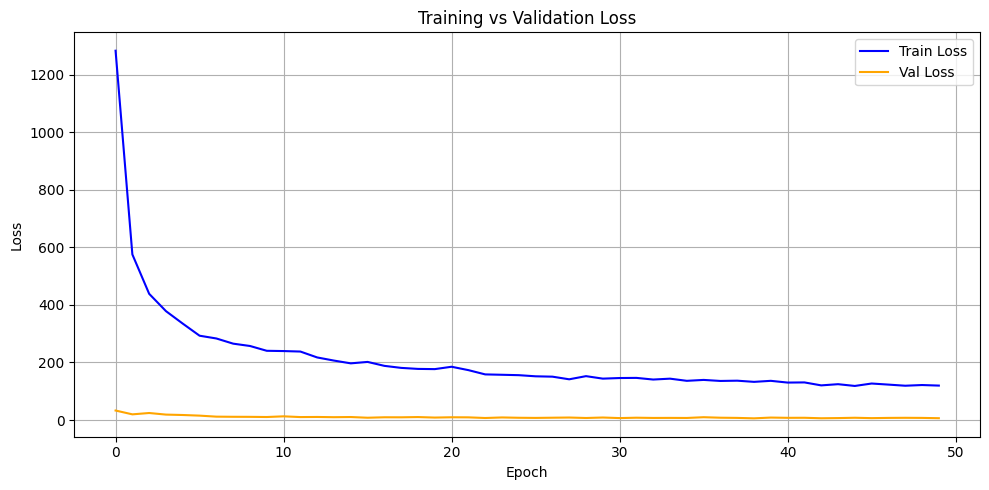

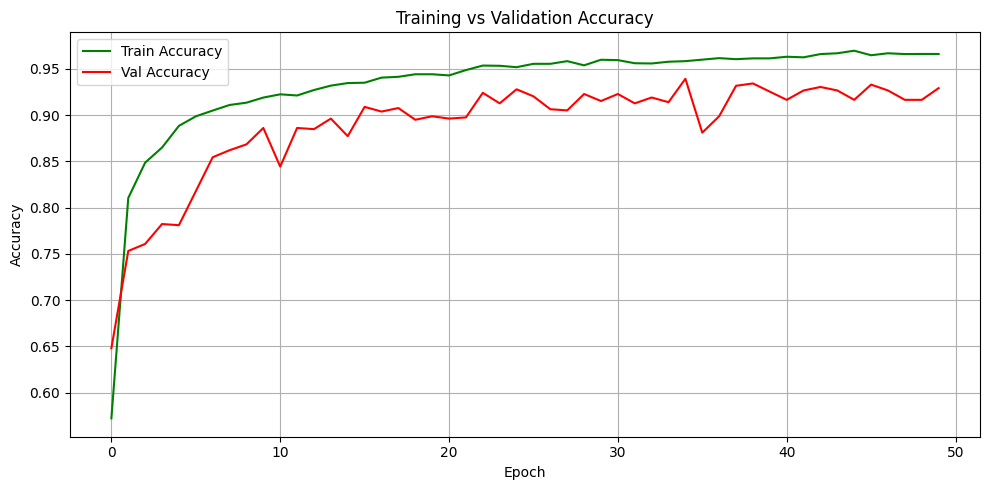

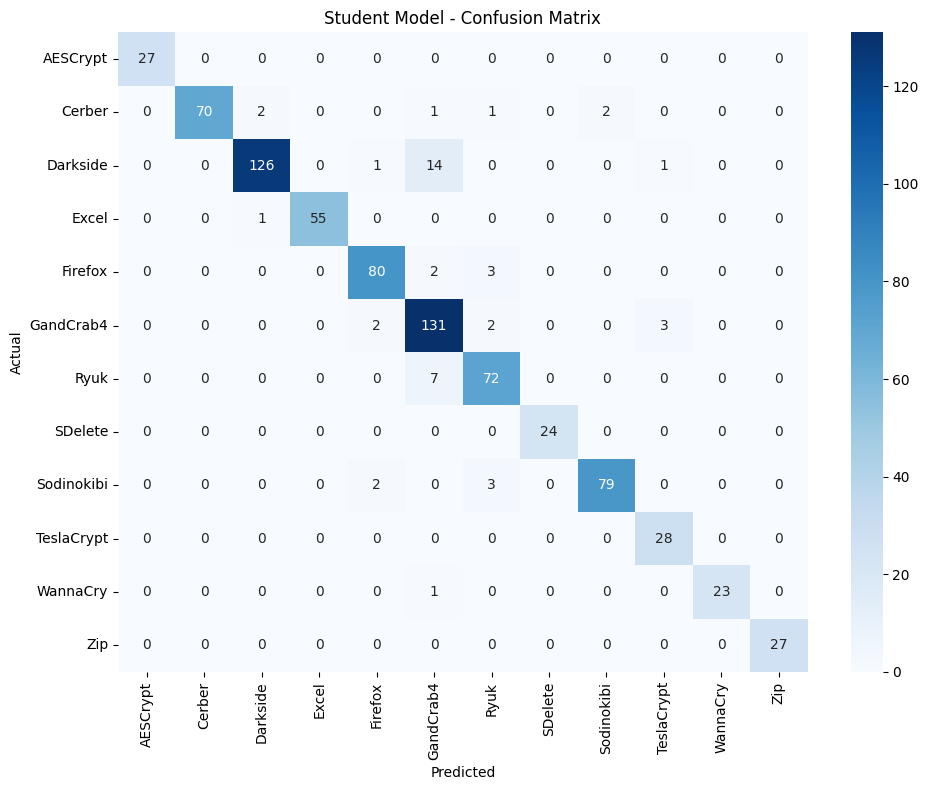


Final Classification Report (Student):

              precision    recall  f1-score   support

    AESCrypt       1.00      1.00      1.00        27
      Cerber       1.00      0.92      0.96        76
    Darkside       0.98      0.89      0.93       142
       Excel       1.00      0.98      0.99        56
     Firefox       0.94      0.94      0.94        85
   GandCrab4       0.84      0.95      0.89       138
        Ryuk       0.89      0.91      0.90        79
     SDelete       1.00      1.00      1.00        24
  Sodinokibi       0.98      0.94      0.96        84
  TeslaCrypt       0.88      1.00      0.93        28
    WannaCry       1.00      0.96      0.98        24
         Zip       1.00      1.00      1.00        27

    accuracy                           0.94       790
   macro avg       0.96      0.96      0.96       790
weighted avg       0.94      0.94      0.94       790


Final Training Accuracy: 0.9660
Final Validation Accuracy: 0.9291


In [78]:
# === Load frozen teacher
teacher = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
teacher.load_state_dict(torch.load("teacher_full.pth", map_location=device))
teacher.to(device)
teacher.eval()


model_for_lr = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model_for_lr.parameters(), lr=1e-7)  # Fresh model + optimizer

print("🔍 Finding optimal learning rate...")
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
lr_finder = LRFinder(model_for_lr, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=1, num_iter=200)
lr_finder.plot()
lr_finder.reset()

# === Use best LR after checking the LR plot
BEST_LR = 0.01  # Replace this based on your LR curve

# === Train student with KD
student = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
train_accs, val_accs, train_losses, val_losses = train_distilled(
    student, teacher, train_loader, val_loader, device,
    epochs=NUM_EPOCHS, lr=BEST_LR, class_weights=class_weights_tensor,
    T=3.0, alpha=0.5
)

# === Plot
plot_loss_curve(train_losses, val_losses)
plot_accuracy_curve(train_accs, val_accs)

# === Evaluate
student.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = student(streams)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Report
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Student Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Classification Report (Student):\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))
print(f"\nFinal Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")


In [79]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_student_baseline(student, train_loader, val_loader, device,
                           epochs=50, lr=0.0005, class_weights=None, save_path="best_student_baseline.pth"):

    student.to(device)
    optimizer = optim.Adam(student.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_acc = 0
    train_losses, train_accuracies, val_accuracies, val_losses = [], [], [], []

    for epoch in range(epochs):
        student.train()
        total_loss = 0
        correct = 0

        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            outputs = student(streams)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        student.eval()
        val_correct = 0
        val_loss = 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)

                outputs = student(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)

        print(f"[Baseline] Epoch {epoch+1:02d}/{epochs} - Loss: {total_loss:.4f} "
              f"- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        # ✅ Save best model checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student.state_dict(), save_path)

    # ✅ Load the best saved model after full training
    student.load_state_dict(torch.load(save_path))
    return train_accuracies, val_accuracies, train_losses, val_losses


In [80]:
# === BASELINE STUDENT TRAINING (No KD) ===
student_baseline = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))

train_accs_b, val_accs_b, train_losses_b, val_losses_b = train_student_baseline(
    student_baseline, train_loader, val_loader, device,
    epochs=NUM_EPOCHS, lr=0.001, class_weights=class_weights_tensor
)
# === Save model
# torch.save(student_baseline.state_dict(), "student_baseline.pth")
print("✅ saved as student_baseline.pth'")

[Baseline] Epoch 01/50 - Loss: 368.9913 - Train Acc: 0.4909 - Val Acc: 0.5722
[Baseline] Epoch 02/50 - Loss: 197.9496 - Train Acc: 0.7421 - Val Acc: 0.6582
[Baseline] Epoch 03/50 - Loss: 142.0699 - Train Acc: 0.8059 - Val Acc: 0.7076
[Baseline] Epoch 04/50 - Loss: 117.3627 - Train Acc: 0.8417 - Val Acc: 0.7316
[Baseline] Epoch 05/50 - Loss: 103.4961 - Train Acc: 0.8595 - Val Acc: 0.7595
[Baseline] Epoch 06/50 - Loss: 92.7720 - Train Acc: 0.8708 - Val Acc: 0.7962
[Baseline] Epoch 07/50 - Loss: 86.8986 - Train Acc: 0.8779 - Val Acc: 0.7772
[Baseline] Epoch 08/50 - Loss: 79.4698 - Train Acc: 0.8880 - Val Acc: 0.7848
[Baseline] Epoch 09/50 - Loss: 75.4180 - Train Acc: 0.8924 - Val Acc: 0.8152
[Baseline] Epoch 10/50 - Loss: 71.5837 - Train Acc: 0.9036 - Val Acc: 0.8139
[Baseline] Epoch 11/50 - Loss: 69.6705 - Train Acc: 0.9025 - Val Acc: 0.8304
[Baseline] Epoch 12/50 - Loss: 66.6968 - Train Acc: 0.9073 - Val Acc: 0.8278
[Baseline] Epoch 13/50 - Loss: 65.5392 - Train Acc: 0.9091 - Val Acc: 0

/tmp/ipykernel_696185/1403345829.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(save_path))


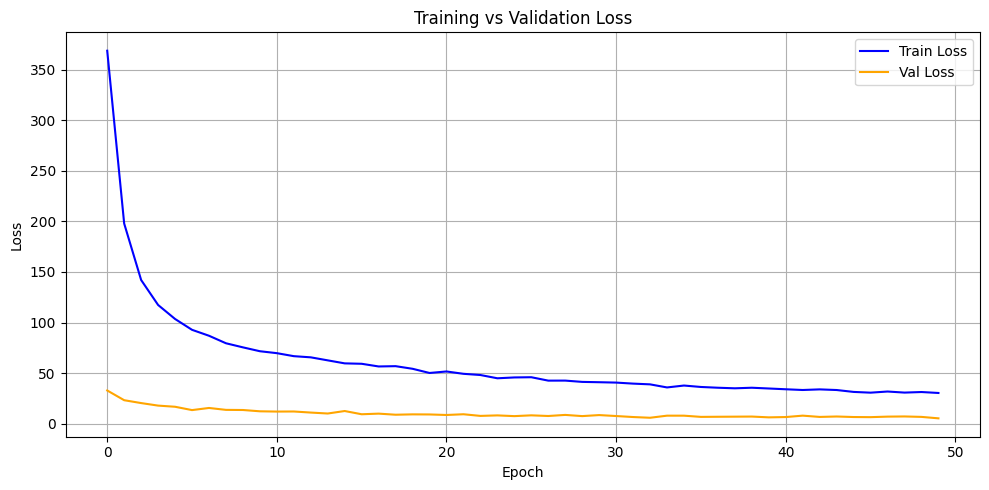

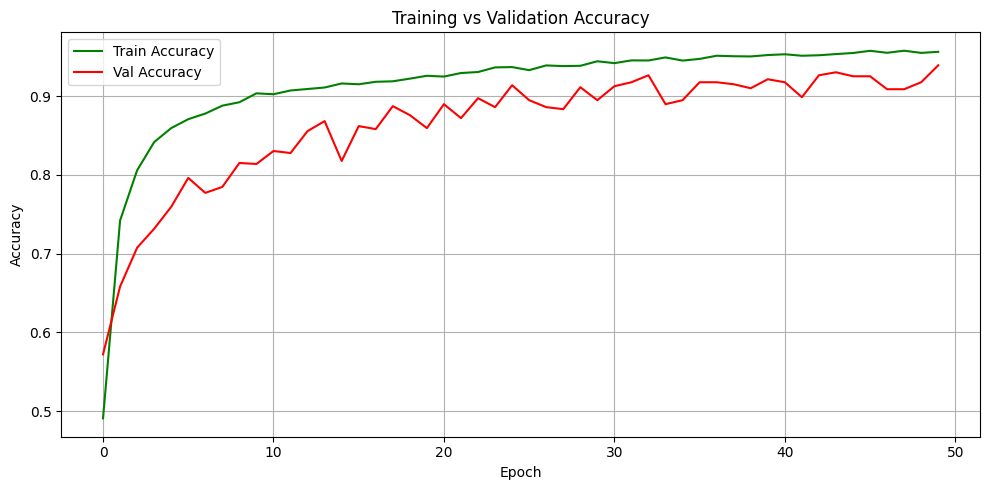

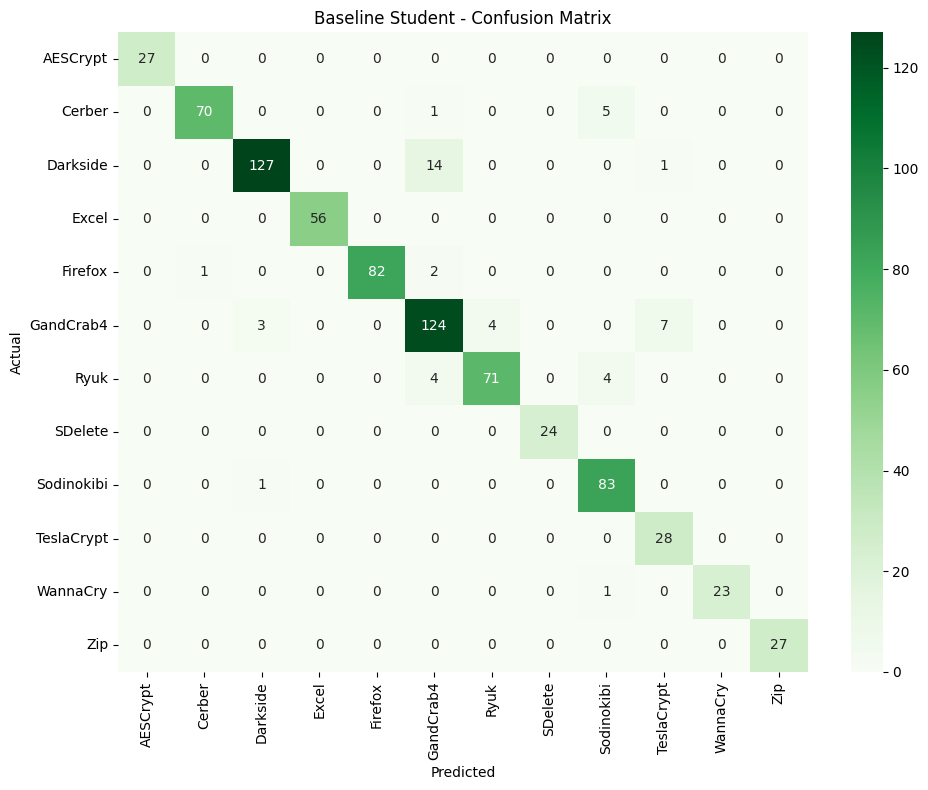


📋 Baseline Classification Report (Student, No KD):

              precision    recall  f1-score   support

    AESCrypt       1.00      1.00      1.00        27
      Cerber       0.99      0.92      0.95        76
    Darkside       0.97      0.89      0.93       142
       Excel       1.00      1.00      1.00        56
     Firefox       1.00      0.96      0.98        85
   GandCrab4       0.86      0.90      0.88       138
        Ryuk       0.95      0.90      0.92        79
     SDelete       1.00      1.00      1.00        24
  Sodinokibi       0.89      0.99      0.94        84
  TeslaCrypt       0.78      1.00      0.88        28
    WannaCry       1.00      0.96      0.98        24
         Zip       1.00      1.00      1.00        27

    accuracy                           0.94       790
   macro avg       0.95      0.96      0.95       790
weighted avg       0.94      0.94      0.94       790

✅ Final Training Accuracy (baseline): 0.9564
✅ Final Validation Accuracy (baseli

In [81]:
student_baseline.eval()
final_preds_b, final_labels_b = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = student_baseline(streams)
        preds = torch.argmax(outputs, dim=1)
        final_preds_b.extend(preds.cpu().numpy())
        final_labels_b.extend(labels.cpu().numpy())
# === Plot
plot_loss_curve(train_losses_b, val_losses_b)
plot_accuracy_curve(train_accs_b, val_accs_b)
# Confusion matrix
cm_b = confusion_matrix(final_labels_b, final_preds_b)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Baseline Student - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Report
print("\n📋 Baseline Classification Report (Student, No KD):\n")
print(classification_report(final_labels_b, final_preds_b, target_names=label_encoder.classes_))
print(f"✅ Final Training Accuracy (baseline): {train_accs_b[-1]:.4f}")
print(f"✅ Final Validation Accuracy (baseline): {val_accs_b[-1]:.4f}")


In [82]:
expected_shape = (CHUNK_SIZE, NUM_FEATURES)
X_test, y_test = load_split_from_folder(os.path.join(INPUT_DIR, "test"), expected_shape)
y_test_str = y_test

test_dataset = MultiStreamDataset(X_test, y_test_str, label_encoder, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


/tmp/ipykernel_696185/952631451.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_student_baseline.pth"))


=== 🧪 Final Test Set Classification Report ===
              precision    recall  f1-score   support

    AESCrypt     0.9000    1.0000    0.9474        27
      Cerber     0.9605    0.9865    0.9733        74
    Darkside     0.9852    0.9500    0.9673       140
       Excel     0.9324    0.9324    0.9324        74
     Firefox     0.9880    1.0000    0.9939        82
   GandCrab4     0.9191    0.8865    0.9025       141
        Ryuk     0.8919    0.8148    0.8516        81
     SDelete     1.0000    1.0000    1.0000        27
  Sodinokibi     0.8706    0.8916    0.8810        83
  TeslaCrypt     0.8043    0.9737    0.8810        38
    WannaCry     0.9697    1.0000    0.9846        32
         Zip     1.0000    1.0000    1.0000        27

    accuracy                         0.9346       826
   macro avg     0.9351    0.9530    0.9429       826
weighted avg     0.9358    0.9346    0.9345       826



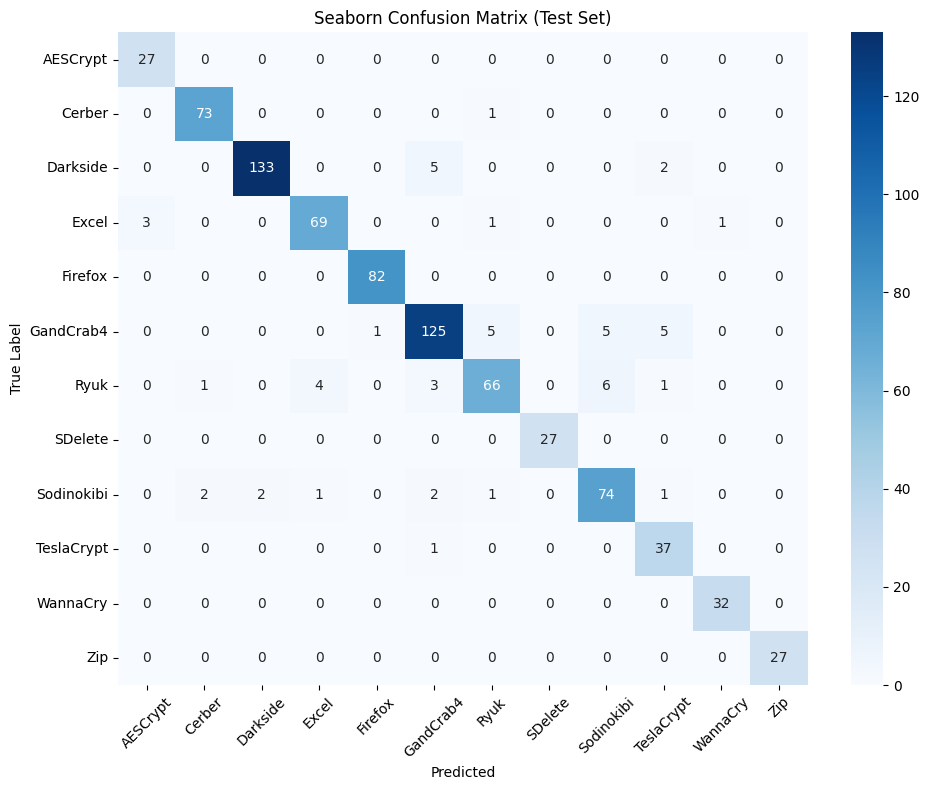

In [83]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Rebuild same model architecture
model = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("best_student_baseline.pth"))
model.to(device)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for streams, labels in test_loader:
        # Move to device
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)

        outputs = model(streams)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Inverse-transform for reporting
pred_labels_str = label_encoder.inverse_transform(all_preds)
true_labels_str = label_encoder.inverse_transform(all_labels)

# === 5. Classification Report
print("=== 🧪 Final Test Set Classification Report ===")
print(classification_report(true_labels_str, pred_labels_str, digits=4))

# === 6. Seaborn Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Seaborn Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [84]:
import torch
import torch.nn as nn
import time
import os
import psutil
import numpy as np
from thop import profile  
def get_model_size(model):
    temp_path = "temp_model.pth"
    torch.save(model.state_dict(), temp_path)
    size = os.path.getsize(temp_path) / (1024 ** 2)  # in MB
    os.remove(temp_path)
    return size

def measure_latency(model, input_shape=(1, 1, 32), n_runs=100):
    model.eval()
    inputs = [torch.randn(input_shape) for _ in range(n_runs)]
    with torch.no_grad():
        start = time.time()
        for inp in inputs:
            model(inp.unsqueeze(0))
        end = time.time()
    avg_latency = (end - start) / n_runs * 1000  # in ms
    return avg_latency

def measure_cpu_usage(model, input_tensor, duration=2):
    model.eval()
    process = psutil.Process(os.getpid())
    cpu_percent_before = process.cpu_percent(interval=None)
    
    with torch.no_grad():
        start_time = time.time()
        while time.time() - start_time < duration:
            model(input_tensor)
    
    cpu_percent_after = process.cpu_percent(interval=None)
    return (cpu_percent_after - cpu_percent_before) / duration

def evaluate_model_stats(model):
    device = next(model.parameters()).device
    dummy_inputs = [torch.randn(1, 1, 32).to(device) for _ in range(8)]

    # Compute MACs and Params
    macs, params = profile(model, inputs=(dummy_inputs,), verbose=False)
    flops = 2 * macs

    # Model size
    size = get_model_size(model)

    # Latency on CPU
    model_cpu = model.to("cpu")
    dummy_inputs_cpu = [inp.to("cpu") for inp in dummy_inputs]

    def measure_latency(model, inputs, n_runs=100):
        model.eval()
        with torch.no_grad():
            start = time.time()
            for _ in range(n_runs):
                model(inputs)
            end = time.time()
        return (end - start) / n_runs * 1000

    def measure_cpu_usage(model, inputs, duration=2):
        model.eval()
        process = psutil.Process(os.getpid())
        num_cpus = psutil.cpu_count(logical=True)

        _ = process.cpu_percent(interval=None)  # warm-up
        
        with torch.no_grad():
            start_time = time.time()
            while time.time() - start_time < duration:
                model(inputs)

        total_cpu_percent = process.cpu_percent(interval=None)
        return total_cpu_percent / num_cpus

    latency = measure_latency(model_cpu, dummy_inputs_cpu)
    cpu_usage = measure_cpu_usage(model_cpu, dummy_inputs_cpu)

    return {
        "Model Size (MB)": round(size, 4),
        "Latency (ms)": round(latency, 3),
        "MACs": macs,
        "FLOPs": flops,
        "Params": params,
        "CPU Usage (%)": round(cpu_usage, 2)
    }

# === Run
model.eval()
stats = evaluate_model_stats(model)
for k, v in stats.items():
    print(f"{k}: {v}")

Model Size (MB): 0.0624
Latency (ms): 1.189
MACs: 25768.0
FLOPs: 51536.0
Params: 7652.0
CPU Usage (%): 49.99
